# Multimodal Parser Demo

Test parsing, indexing, and RAG agent functionalities.

In [1]:
from dotenv import load_dotenv
load_dotenv("../.env")
from IPython.display import Image as IPImage, display
from multimodal_parser import DoclingParser, ChunkType, RAGAgent, render
from multimodal_parser.indexer import DocumentIndexer
from IPython.display import JSON, display

import pandas as pd
import json

import warnings
import logging
warnings.filterwarnings('ignore')
logging.disable(logging.CRITICAL)


## 1. Parse PDF

In [2]:
parser = DoclingParser()
chunks = parser.parse("../data/files/rag_paper.pdf")

text_chunks = [c for c in chunks if c.chunk_type == ChunkType.TEXT]
table_chunks = [c for c in chunks if c.chunk_type == ChunkType.TABLE]
image_chunks = [c for c in chunks if c.chunk_type == ChunkType.IMAGE]

print(f"Total: {len(chunks)} | Text: {len(text_chunks)} | Tables: {len(table_chunks)} | Images: {len(image_chunks)}")

Loading weights:   0%|          | 0/770 [00:00<?, ?it/s]

Total: 49 | Text: 38 | Tables: 7 | Images: 4


In [3]:
# Sample text chunk
if text_chunks:
    c = json.loads(text_chunks[8].json())
    print("\n[TEXT CHUNK]")
    display(JSON(c))


[TEXT CHUNK]


<IPython.core.display.JSON object>

In [4]:
# Sample table chunk
if table_chunks:
    c = table_chunks[4].copy()
    table = table_chunks[4].dataframe
    c.dataframe = c.dataframe.to_json()
    c = json.loads(c.json())
    print("\n[TABLE CHUNK]")
    display(pd.DataFrame(table))
    display(JSON(c))


[TABLE CHUNK]


,,MSMARCO,Jeopardy QGen
0,Gold,89.6%,90.0%
1,BART,70.7%,32.4%
2,RAG-Token,77.8%,46.8%
3,RAG-Seq.,83.5%,53.8%


<IPython.core.display.JSON object>


[IMAGE CHUNK]


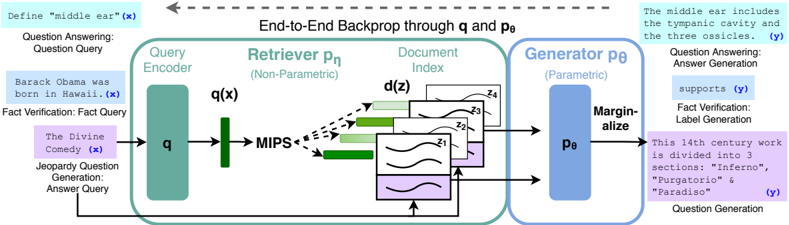

<IPython.core.display.JSON object>

In [5]:
# Sample image chunk
if image_chunks:
    c = json.loads(image_chunks[0].json())
    print("\n[IMAGE CHUNK]")
    if c["image_path"]:
        display(IPImage(filename=c["image_path"], width=500))
        c["image_base64"] = c["image_base64"][:10]+"...."
        display(JSON(c))

## 2. Index to Qdrant

In [6]:
indexer = DocumentIndexer(qdrant_path="../qdrant_data", force_reset=True)
count = indexer.index_folder("../data/files")
print(f"Indexed {count} chunks")
indexer.close()

Loading weights:   0%|          | 0/770 [00:00<?, ?it/s]

Indexed 149 chunks


### View all chunks in the vector DB

Scroll every point in the `document_chunks` collection (payload only; no vectors).

In [7]:
from qdrant_client import QdrantClient
from multimodal_parser.indexer import COLLECTION_NAME
import pandas as pd

client = QdrantClient(path="../qdrant_data")
points, offset = [], None
while True:
    batch, offset = client.scroll(
        collection_name=COLLECTION_NAME,
        limit=256,
        offset=offset,
        with_payload=True,
        with_vectors=False,
    )
    points.extend(batch)
    if offset is None:
        break

rows = []
for p in points:
    pl = p.payload or {}
    rows.append({
        "chunk_type": pl.get("chunk_type"),
        "chunk_id": pl.get("chunk_id"),
        "source": pl.get("source_document"),
        "page": pl.get("source_page"),
        "preview": (pl.get("content") or ""),
    })
client.close()

print(f"Total points: {len(rows)}")
df = pd.DataFrame(rows)
df

Total points: 149


,chunk_type,chunk_id,source,page,preview
0,image,image_38,rag_paper.pdf,2,This is a detailed and helpful description for...
1,text,text_13,llm_as_a_judge.pdf,11,Reliability Concerns of Model Selection\nThe c...
2,table,table_42,rag_paper.pdf,7,This table contains sample outputs from Natura...
3,image,image_90,llm_as_a_judge.pdf,25,This is a descriptive analysis of the provided...
4,text,text_59,llm_as_a_judge.pdf,50,7.10 Domain-Specific Reliable Applications\nTh...
...,...,...,...,...,...
144,text,text_57,llm_as_a_judge.pdf,50,7.8 LLM-as-a-Judge for Embodied Intelligence\n...
145,text,text_58,llm_as_a_judge.pdf,50,7.9 LLM-as-a-Judge for LLM Optimization\nLLM-a...
146,table,table_39,rag_paper.pdf,6,This table contains numerical test scores for ...
147,text,text_35,llm_as_a_judge.pdf,32,4.4.2 Results and Analysis .\nComparison with ...


## 3. Query with RAG Agent

In [8]:
agent = RAGAgent(qdrant_path="../qdrant_data", top_k=5)

This diagram illustrates the architecture of the Retrieval-Augmented Generation (RAG) model.

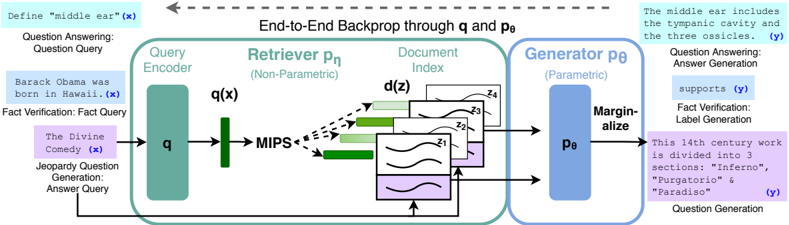

The retriever and generator components work together in a two-stage process:

1.  **Retriever**: This component acts as a non-parametric memory. Given an input query (`x`), the retriever's Query Encoder creates a representation of that query. It then uses this representation to search a Document Index (in this case, a dense vector index of Wikipedia) via Maximum Inner Product Search (MIPS). The retriever's goal is to find the top-K most relevant text documents (`z`) for the given input. This component is based on the Dense Passage Retriever (DPR).

2.  **Generator**: This component is a parametric memory, specifically a pre-trained seq2seq model like BART. It takes the original input (`x`) and the documents (`z`) retrieved by the first component and uses both as context to generate the final output sequence (`y`).

The entire model, including both the retriever and the generator, is trained end-to-end, which allows both components to be jointly learned and fine-tuned for the specific task.

**Sources:** llm_as_a_judge.pdf (page 39), rag_paper.pdf (page 3), rag_paper.pdf (page 1), llm_as_a_judge.pdf (page 15), rag_paper.pdf (page 2), rag_paper.pdf (page 7), rag_paper.pdf (page 8), llm_as_a_judge.pdf (page 25)

In [9]:
# sample query
result = agent.query("Show me the architecture diagram of RAG and explain how the retriever and generator components work together")
render(result)

In [10]:
# sample query
result = agent.query("From the LLM-as-a-Judge paper results table, which model has the highest agreement rate with human judges? List the top 3 models with their exact scores.")
render(result)

Based on the results, here are the top 3 models with the highest agreement rate with human judges:

1.  **o3-mini**: 61.66
2.  **GPT-4-turbo**: 61.54
3.  **gemini-2.0-thinking**: 60.75

**Sources:** llm_as_a_judge.pdf (page 5), llm_as_a_judge.pdf (page 7), llm_as_a_judge.pdf (page 1), llm_as_a_judge.pdf (page 31), llm_as_a_judge.pdf (page 25), llm_as_a_judge.pdf (page 13), llm_as_a_judge.pdf (page 18), llm_as_a_judge.pdf (page 8), llm_as_a_judge.pdf (page 20)

The overall framework of the LLM-as-a-Judge survey is shown below. It breaks down the concept into its definition, usage, improvement, evaluation, applications, challenges, and future work.

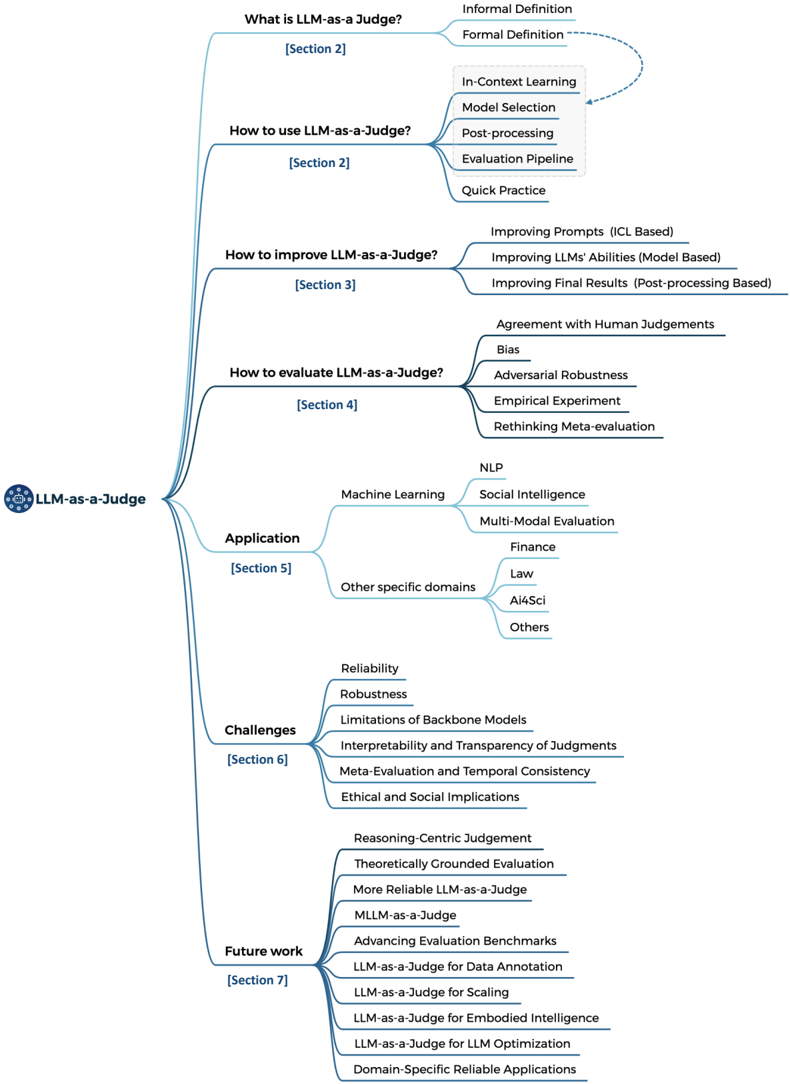

The LLM-as-a-Judge evaluation pipeline shows four typical evaluation scenarios or task formats: Scores, Yes or No, Pairs, and Multiple-choice.

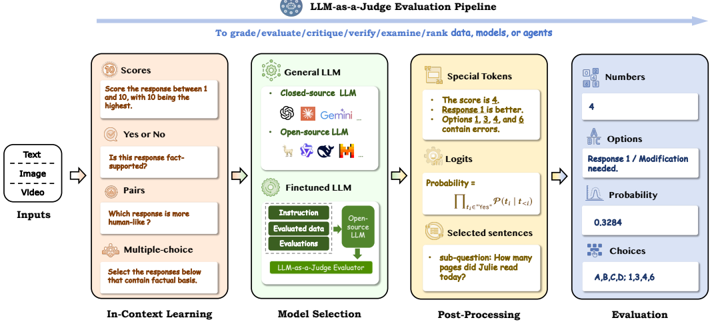

The structure for improving and evaluating LLM-as-a-Judge systems is detailed in the following diagram, which covers strategies for improvement and areas for evaluation.

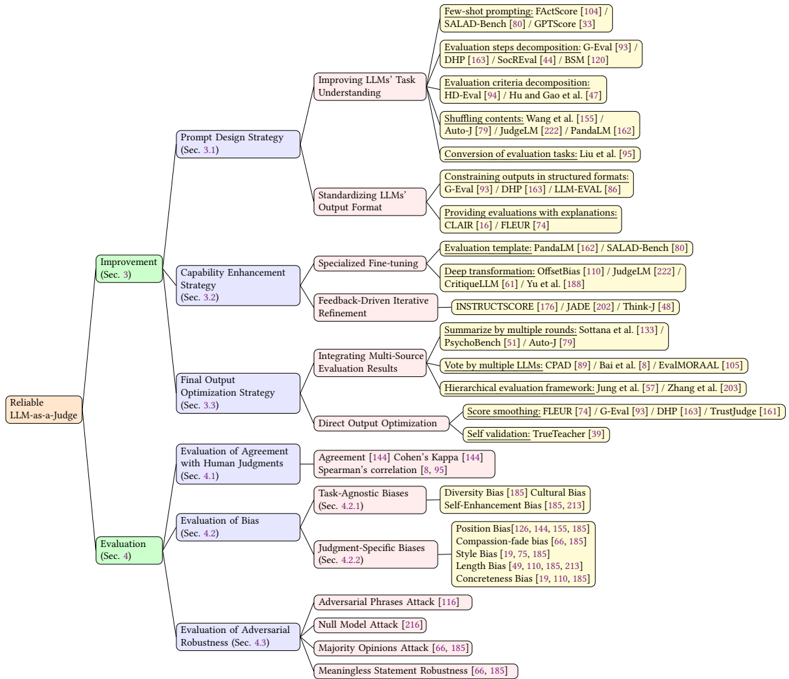

**Sources:** llm_as_a_judge.pdf (page 5), llm_as_a_judge.pdf (page 2), llm_as_a_judge.pdf (page 7), llm_as_a_judge.pdf (page 1), llm_as_a_judge.pdf (page 29), llm_as_a_judge.pdf (page 25), llm_as_a_judge.pdf (page 4), llm_as_a_judge.pdf (page 18), llm_as_a_judge.pdf (page 51), llm_as_a_judge.pdf (page 20)

In [11]:
#sample query
result = agent.query("Show me the overall framework of the LLM-as-a-Judge survey, the four typical evaluation scenarios, and the structure for how to improve and evaluate LLM-as-a-Judge systems.")
render(result)
            

In [12]:
agent.close()